# 04 - Injected Anomaly Dataset Review

## Notebook Objectives
- Inspect the anomaly-labeled dataset structure, row counts, and injected-anomaly counts before detection.
- Confirm that injected anomaly types are present and aligned with expected failure modes.
- Visualize injected anomalies as a final quality check before running detection and evaluation in notebook 05.

## Load anomaly artifact

We load the prepared `anomaly_injected` dataset directly, keeping notebooks aligned with the scripts.

In [4]:
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))

from config import ANOMALY_INJECTED_DATA, INJECTED_ANOMALIES
from src.visualization.plots import plot_injected_anomalies

In [5]:
anomaly_df = pd.read_csv(ANOMALY_INJECTED_DATA, parse_dates=["date"])
injected_count = int(anomaly_df["is_injected_anomaly"].sum())

# print(f"Loaded anomaly-labelled data from {ANOMALY_INJECTED_DATA}")
print(f"Rows: {len(anomaly_df)}")
print(f"Injected anomalies: {injected_count}")
print(anomaly_df[["date", "daily_trip_count", "true_anomaly_type", "is_injected_anomaly"]].head(10))

Rows: 59
Injected anomalies: 15
        date  daily_trip_count true_anomaly_type  is_injected_anomaly
0 2023-01-01           76752.0              none                    0
1 2023-01-02           65777.0              none                    0
2 2023-01-03           85783.0              none                    0
3 2023-01-04           95092.0              none                    0
4 2023-01-05          101063.0              none                    0
5 2023-01-06               0.0         zero_load                    1
6 2023-01-07          105036.0              none                    0
7 2023-01-08           85056.0              none                    0
8 2023-01-09           85349.0              none                    0
9 2023-01-10           99916.0              none                    0


## Visualize the injected anomalies

A quick visual check that the injected points look like the failure modes we intended, before we ask the detector to find them in notebook 05.

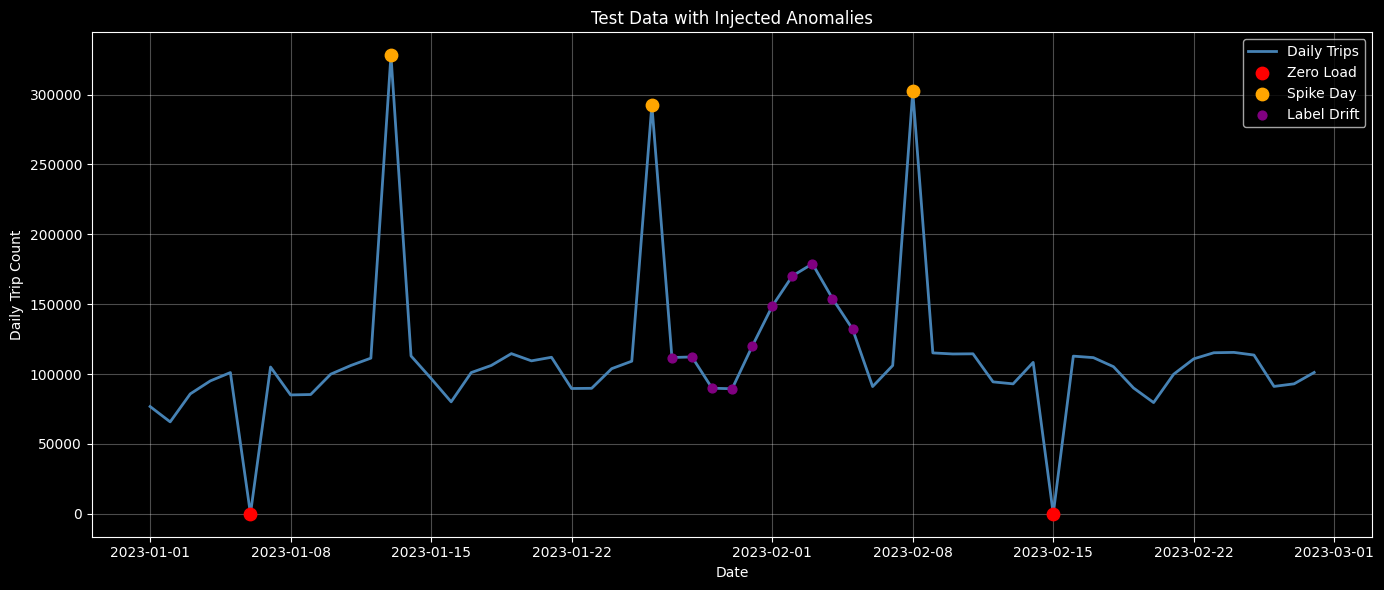

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Test Data with Injected Anomalies'}, xlabel='Date', ylabel='Daily Trip Count'>)

In [6]:
plot_injected_anomalies(
    df=anomaly_df,
    output_path=INJECTED_ANOMALIES,
    show=True,
)

# print(f"Saved injected-anomaly plot to {INJECTED_ANOMALIES}")